c:\Users\jason\Code\Python\engr418\.venv\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


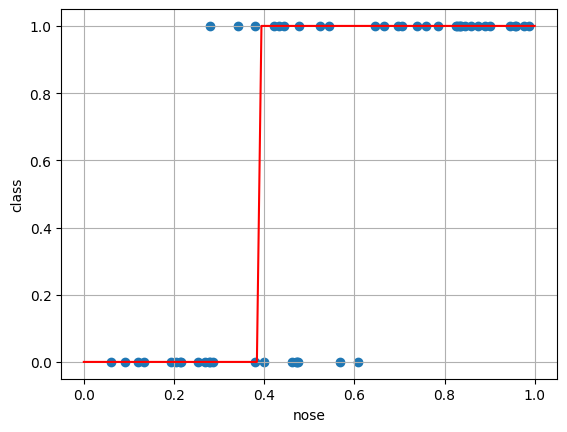

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# read dataset
df = pd.read_csv("./data_sets/cat-dog.csv")
# print(df)
x = np.array(df["nose"]).reshape(-1, 1)
y = np.array(df["class"]).reshape(-1, 1)

# split and plot
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33)
plt.scatter(x_train, y_train)
plt.xlabel("Nose")
plt.ylabel("Class")
plt.grid(1)

# train model
model = LogisticRegression()
model.fit(x_train, y_train)

# plotting the model
x_plot = np.linspace(0, 1, 100).reshape(-1, 1)
y_plot = model.predict(x_plot)
plt.plot(x_plot, y_plot, "r-")

In [10]:
# calculate accuracy
y_pred = model.predict(x_test).reshape(-1, 1)
print( np.hstack((x_test, y_test, y_pred)) )
print(confusion_matrix(y_test, y_pred), accuracy_score(y_test, y_pred))

[[0.55967793 1.         1.        ]
 [0.71447164 1.         1.        ]
 [0.89915643 1.         1.        ]
 [0.03483382 0.         0.        ]
 [0.10963261 0.         0.        ]
 [0.60772697 1.         1.        ]
 [0.34300581 0.         0.        ]
 [0.96877766 1.         1.        ]
 [0.54500489 1.         1.        ]
 [0.72308996 1.         1.        ]
 [0.17090323 0.         0.        ]
 [0.40806349 0.         1.        ]
 [0.20371543 0.         0.        ]
 [0.55544354 0.         1.        ]
 [0.94800236 1.         1.        ]
 [0.95960928 1.         1.        ]
 [0.82449942 1.         1.        ]
 [0.92543689 1.         1.        ]
 [0.26901061 1.         0.        ]
 [0.9912032  1.         1.        ]
 [0.33975716 0.         0.        ]
 [0.52410601 0.         1.        ]
 [0.33337269 0.         0.        ]
 [0.38293799 0.         0.        ]
 [0.43777311 1.         1.        ]
 [0.54299169 1.         1.        ]
 [0.02762901 0.         0.        ]]
[[ 9  3]
 [ 1 14]] 0.851851

Modelling with 2 Parameters

c:\Users\jason\Code\Python\engr418\.venv\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion matrix:
 [[12  0]
 [ 0 15]]
Accuracy:
 1.0


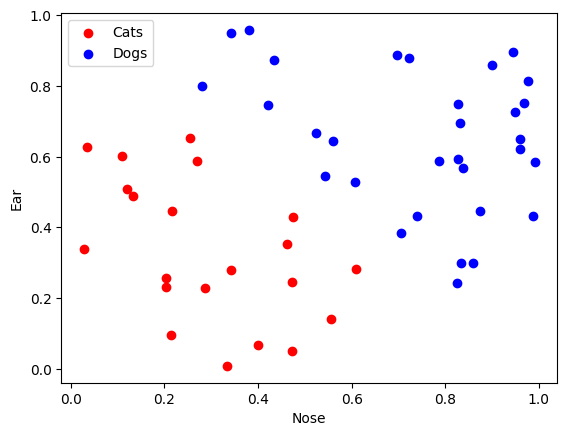

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# read dataset
df = pd.read_csv("./data_sets/cat-dog.csv")
# print(df)
x1 = df["nose"]
x2 = df["ear"]
x = np.array([x1, x2]).T
y = np.array(df["class"]).reshape(-1, 1)

# split and plot
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33)
plt.scatter(x_train[y_train[:, 0] == 0, 0], x_train[y_train[:, 0] == 0, 1], c = "r", label = "Cats")
plt.scatter(x_train[y_train[:, 0] == 1, 0], x_train[y_train[:, 0] == 1, 1], c = "b", label = "Dogs")
plt.xlabel("Nose")
plt.ylabel("Ear")
plt.legend()

# train model
model = LogisticRegression(penalty = None)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:\n", accuracy_score(y_test, y_pred))

(100, 100) (100, 100)
(10000, 1) (10000, 1)
(10000,)
(100, 100)


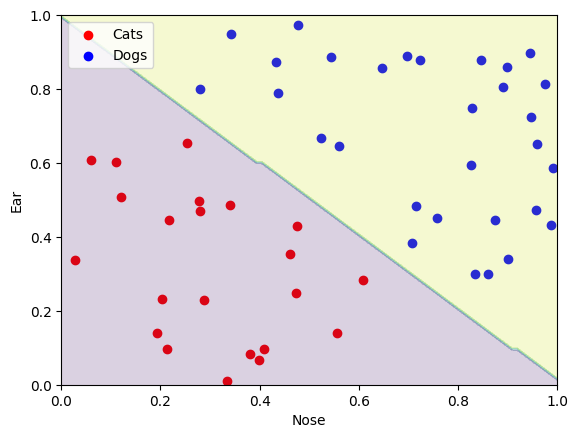

In [30]:
x1_plot = np.linspace(0, 1, 100)
x2_plot = np.linspace(0, 1, 100)
xp1, xp2 = np.meshgrid(x1_plot, x2_plot)
print(xp1.shape, xp2.shape)
xp1_v = xp1.reshape(-1, 1)
xp2_v = xp2.reshape(-1, 1)
print(xp1_v.shape, xp2_v.shape)

xp = np.hstack((xp1_v, xp2_v))
yp = model.predict(xp)
print(yp.shape)
yp = yp.reshape(xp1.shape)
print(yp.shape)

plt.scatter(x_train[y_train[:, 0] == 0, 0], x_train[y_train[:, 0] == 0, 1], c = "r", label = "Cats")
plt.scatter(x_train[y_train[:, 0] == 1, 0], x_train[y_train[:, 0] == 1, 1], c = "b", label = "Dogs")
plt.xlabel("Nose")
plt.ylabel("Ear")
plt.legend()
plt.contourf(xp1, xp2, yp, alpha = 0.2)